# Pneumonia Detection using CNN

## Project Goal

The primary objective of this study is to develop a robust Convolutional Neural Network (CNN) capable of identifying pneumonia patterns in pediatric X-ray images. The project focuses on three key pillars:


- **Model Performance & Generalization**:

  - Implementing and comparing state-of-the-art architectures, specifically ResNet50 and VGG16, to achieve high diagnostic accuracy on unseen test data.


  - Addressing the challenge of Dataset Shift by utilizing advanced Data Augmentation (rotation, flipping, contrast adjustment) to ensure the model learns biological features rather than image artifacts.

- **Explainability & Trust (XAI):**

  - Implementing Grad-CAM (Gradient-weighted Class Activation Mapping) to visualize the model's decision-making process.

  - The goal is to ensure the network focuses on the pulmonary parenchyma (lung tissue) rather than "shortcuts" like skeletal structures (neck, clavicles) or image metadata.

- **Data Quality Control:**

  - Applying Central Cropping and preprocessing techniques to isolate the lungs and minimize the impact of non-diagnostic spatial biases.


- **Dataset:**

  - The model is trained on the Chest X-Ray Images (Pneumonia) dataset, consisting of thousands of validated B-mode images. The evaluation is conducted on a strictly independent test set to measure real-world reliability.

## Imports

In [33]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import cv2
from scipy.ndimage import zoom
import shutil
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## Data Preprocessing

### Data Loading

The dataset is stored on Google Drive and copied to the local Colab runtime for faster input/output performance during training.

Working directly from Google Drive can significantly slow down training due to I/O limitations. To address this, the dataset is copied to the local `/content` directory, which provides much faster access.

The dataset has the following structure:

- train/
- val/
- test/

Each directory contains two classes:
- Pneumonia
- Normal

This setup ensures efficient data loading and improved training performance.

In [6]:
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    print("Running in Google Colab")

    from google.colab import drive
    drive.mount('/content/drive')

    drive_data = "/content/drive/MyDrive/chest_xray"
    local_data = "/content/chest_xray"

    # If has not copied yet -> copy
    if not os.path.exists(local_data):
        print("Copying dataset to local runtime (fast)...")
        shutil.copytree(drive_data, local_data)
        print("Copy complete.")

    data_dir = local_data

else:
    print("Running locally")
    data_dir = os.path.join(os.getcwd(), "data", "chest_xray")


# Paths
train_path = os.path.join(data_dir, "train")
val_path = os.path.join(data_dir, "val")
test_path = os.path.join(data_dir, "test")

print("Dataset path:", data_dir)

Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying dataset to local runtime (fast)...
Copy complete.
Dataset path: /content/chest_xray


### Dataset Resizing

Before training, we examine the dataset distribution across the training, validation, and test sets.

The function below counts the number of images in each subset (train, validation, test) by summing the images in both classes:
- Normal
- Pneumonia

This helps verify that the dataset is correctly structured and provides insight into the dataset size.

In [7]:
def print_dataset_summary(data_dir):
    print("Dataset Summary:")
    for subset in ['train', 'val', 'test']:
        subset_path = os.path.join(data_dir, subset)
        if os.path.exists(subset_path):

            total_count = sum([len(os.listdir(os.path.join(subset_path, label)))
                               for label in ['NORMAL', 'PNEUMONIA']
                               if os.path.exists(os.path.join(subset_path, label))])

            print(f"  - {subset.capitalize()}: {total_count} images")
        else:
            print(f"  - {subset.capitalize()}: Directory not found!")

print_dataset_summary(data_dir)

Dataset Summary:
  - Train: 5218 images
  - Val: 16 images
  - Test: 624 images


The dataset is loaded using TensorFlow's `image_dataset_from_directory` utility.

- Images are resized to a fixed resolution of **224×224**, which is required by pretrained CNN architectures such as ResNet50 and VGG16.
- The training dataset is split into training and validation sets using an **80/20 split**.
- A fixed random seed is used to ensure reproducibility.

The test dataset is loaded separately and is not used during training.

In [8]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


# Image and batch sizes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Loading train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Loading validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Loading test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)


# Initialization
train_pneumonia_count = 0
train_normal_count = 0

for images, labels in train_ds:
    train_pneumonia_count += int(tf.reduce_sum(labels))
    train_normal_count += int(len(labels) - tf.reduce_sum(labels))

val_pneumonia_count = 0
val_normal_count = 0
for images, labels in val_ds:
    val_pneumonia_count += int(tf.reduce_sum(labels))
    val_normal_count += int(len(labels) - tf.reduce_sum(labels))

test_pneumonia_count = 0
test_normal_count = 0
for images, labels in test_ds:
    test_pneumonia_count += int(tf.reduce_sum(labels))
    test_normal_count += int(len(labels) - tf.reduce_sum(labels))

# Results
print(f"Train - Normal: {train_normal_count}, Pneumonia: {train_pneumonia_count}")
print(f"Val   - Normal: {val_normal_count}, Pneumonia: {val_pneumonia_count}")
print(f"Test  - Normal: {test_normal_count}, Pneumonia: {test_pneumonia_count}")

Found 5218 files belonging to 2 classes.
Using 4175 files for training.
Found 5218 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
Train - Normal: 1092, Pneumonia: 3083
Val   - Normal: 249, Pneumonia: 794
Test  - Normal: 234, Pneumonia: 390


All images are resized to a uniform input size of **224×224 pixels** to match the input requirements of the neural network models.

To better understand the dataset, a sample batch of validation images is visualized below. This allows us to:
- Verify that images are loaded correctly
- Confirm label assignments (Normal vs Pneumonia)
- Inspect overall data quality

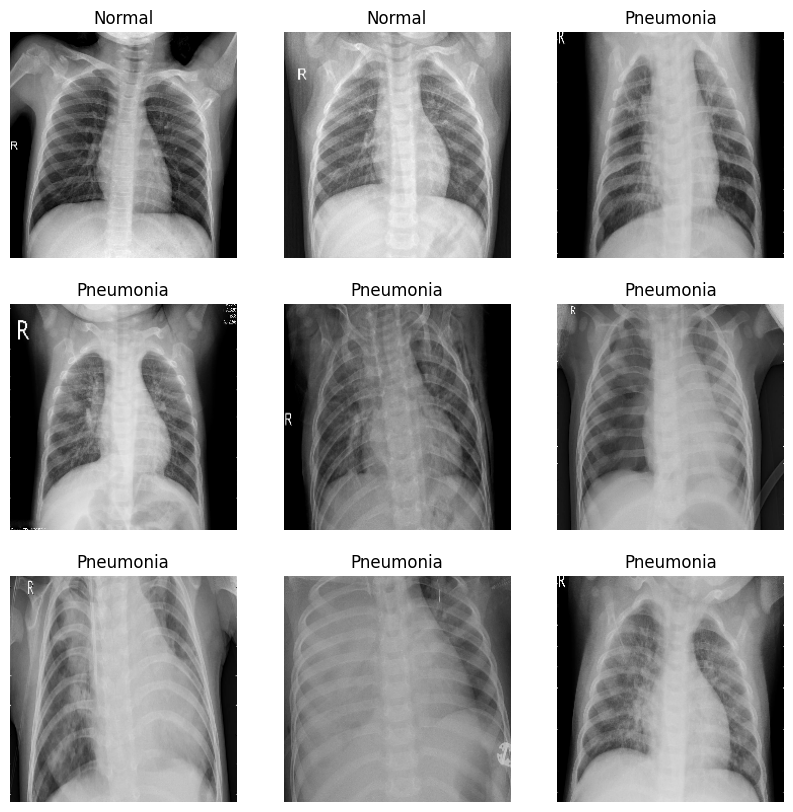

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    for i in range(9): # We are only showing the first 9
        ax = plt.subplot(3, 3, i + 1)

        # Converting the images to uint8
        img = images[i].numpy().astype("uint8")

        plt.imshow(img)

        # Determinig the labels  (0: Normal, 1: Pneumonia)
        label = "Pneumonia" if labels[i] == 1 else "Normal"
        plt.title(label)
        plt.axis("off")

plt.show()

### Data Normalization

Before training, pixel values are normalized to improve model performance and stability.

Original image pixel values range from **0 to 255**. These values are rescaled to the range **[0, 1]** using a rescaling layer.

Normalization helps:
- Improve convergence during training
- Stabilize gradient updates
- Ensure compatibility with pretrained models

The normalization is applied to the training, validation, and test datasets using a TensorFlow mapping function.

In [10]:
# Keras Layer, whish acts as a function
rescaling_layer = tf.keras.layers.Rescaling(scale=1./255)

train_ds = train_ds.map(lambda x, y: (rescaling_layer(x), y))
val_ds = val_ds.map(lambda x, y: (rescaling_layer(x), y))
test_ds = test_ds.map(lambda x, y: (rescaling_layer(x), y))

### Data Augmentation

To improve model generalization and reduce overfitting, data augmentation techniques are applied to the training images.

Data augmentation artificially increases the diversity of the dataset by applying random transformations to the input images during training.

The following transformations are used:
- **Center Cropping** to focus on the most relevant region of the image
- **Resizing** to to ensure a consistent input size (224×224) required by the neural network models
- **Random Horizontal Flip** to introduce invariance to orientation
- **Random Rotation** to simulate slight variations in positioning
- **Random Zoom** to account for scale differences
- **Random Contrast Adjustment** to improve robustness to lighting variations

These transformations help the model generalize better to unseen data.

In [11]:
data_augmentation = tf.keras.Sequential([
  layers.CenterCrop(180, 180),
  layers.Resizing(224, 224),
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.2),
])

## Model Training & Evaluation

In this project, I implemented two distinct deep learning architectures to compare how different transfer learning strategies affect performance on medical X-ray data.



 **Strategy A: VGG16 (Fixed Feature Extraction)**

*   **Architecture:** VGG16 is a classic convolutional neural network consisting of 13 convolutional layers and 3 dense layers. It uses small $3 \times 3$ filters with a stride of 1, consistently doubling the number of filters after each max-pooling layer ($64 \rightarrow 512$).
*   **Configuration:**
    *   **Base Model:** All layers were frozen (`trainable = False`) to preserve the original ImageNet weights.
    *   **Custom Head:** Added a `GlobalAveragePooling2D` layer, followed by a `Dense(256)` layer with ReLU activation, and a `Dropout(0.5)` layer for regularization.
    *   **Parameters:** ~14.7M total, but only ~512,000 trainable parameters.

**Strategy B: ResNet50 (Partial Fine-Tuning)**

*   **Architecture:** ResNet50 (Residual Network) introduced skip connections (residual blocks) to solve the vanishing gradient problem in very deep networks. It consists of 50 layers, including bottleneck blocks that use $1 \times 1$ convolutions to reduce dimensionality.
*   **Configuration:**
    *   **Base Model:** The first 155 layers were frozen, while the last 20 layers (the final convolutional block) were set to `trainable = True`.
    *   **Custom Head:** Identical to the VGG16 setup to ensure a fair comparison of the base models.
    *   **Parameters:** ~24.1M total, with ~4.5M trainable parameters.



 **Hyperparameters Summary**

While both models use the Adam optimizer, the learning rate settings differ to accommodate their respective training strategies:

| Hyperparameter | VGG16 (Feature Extraction) | ResNet50 (Fine-Tuning) |
| :--- | :--- | :--- |
| **Optimizer** | Adam (Default) | Adam (Custom LR) |
| **Learning Rate** | $0.001$ (Default) | $0.00001$ ($1 \times 10^{-5}$) |
| **Input Shape** | $224 \times 224 \times 3$ | $224 \times 224 \times 3$ |
| **Loss Function** | Binary Crossentropy | Binary Crossentropy |
| **Batch Size** | 32 | 32 |



**Why the different Learning Rates?**

1.  VGG16 ($0.001$):  Since the base model is completely frozen, the optimizer only needs to train the newly added Dense layers from scratch. A standard learning rate is appropriate here to allow these new top layers to converge quickly.
2.  ResNet50 ($1 \times 10^{-5}$): Because we unfroze the last 20 layers of the pre-trained ResNet50, we must use a very low learning rate. If the rate were too high, the optimizer would "clobber" or destroy the sophisticated features already learned on ImageNet. The small rate ensures that we only gently fine-tune the weights to the X-ray domain.


**Training Intent:**
-  The goal of this dual approach is to observe whether a fixed, simpler model (VGG16) or a more complex, partially fine-tuned model (ResNet50) provides a more reliable representation of the pathological features in chest X-rays.

### ResNet50

In [12]:
# Load the base model without the top classification layer (include_top=False)
resnet50_base_model = ResNet50(
    include_top=False,         # Remove the 1000-class decision maker
    weights='imagenet',        # Use pre-trained weights (learned shapes, textures)
    input_shape=(224, 224, 3)  # Define input image dimensions
)

# Enable training for the base model
resnet50_base_model.trainable = True

# Fine-tuning strategy: Freeze all layers except the last 20
for layer in resnet50_base_model.layers[:-20]:
    layer.trainable = False

# Add custom classification head
resnet50_model = tf.keras.Sequential([
    data_augmentation,         # Apply data augmentation layers
    resnet50_base_model,       # The feature extractor (ResNet50)
    tf.keras.layers.GlobalAveragePooling2D(), # Flatten the feature maps
    tf.keras.layers.Dense(256, activation='relu'), # Extra layer for lung-specific patterns
    tf.keras.layers.Dropout(0.5), # Regularization to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid') # Final binary decision (0 or 1)
])

# Compile the model
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

resnet50_history = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=0,
    callbacks=[early_stop]
)
print("ResNet50 training complete.")

ResNet50 training complete.


In [14]:
resnet50_loss, resnet50_acc = resnet50_model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.7821 - loss: 0.5548


### VGG16

In [24]:
# Load the base model
vgg16_base_model = VGG16(
    weights='imagenet',       # Remove the 1000-class decision maker
    include_top=False,        # Use pre-trained weights (learned shapes, textures)
    input_shape=(224, 224, 3) # Define input image dimensions
)

# Disable training for the base model
vgg16_base_model.trainable = False

# Add custom classification head
vgg16_model = models.Sequential([
    data_augmentation,    # Apply data augmentation layers
    vgg16_base_model,     # The feature extractor (VGG16)
    layers.GlobalAveragePooling2D(),  # Flatten the feature maps
    layers.Dense(256, activation='relu'), # Extra layer for lung-specific patterns
    layers.Dropout(0.5),  # Regularization to prevent overfitting
    layers.Dense(1, activation='sigmoid')  # Final binary decision (0 or 1)
])


# Compiling the model
vgg16_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)
vgg16_history = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=0,
    callbacks=[early_stop]
)
print("VGG16 training complete.")

VGG16 training complete.


In [27]:
vgg16_loss, vgg16_acc = vgg16_model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8750 - loss: 0.3341


## Model Interpretability with Grad-CAM

To better understand the decision-making process of the trained models, Grad-CAM (Gradient-weighted Class Activation Mapping) is used.

Grad-CAM highlights the regions of an input image that are most important for the model’s prediction. This is particularly useful in medical imaging, where interpretability is critical.

By visualizing these activation maps, we can verify whether the model focuses on clinically relevant areas of the chest X-ray.

The following helper functions are used to:
- Load and preprocess individual images
- Generate Grad-CAM heatmaps using model gradients
- Overlay heatmaps on the original X-ray images for visualization

In [28]:
# Changing the image format to a numpy array
def get_img_array(img_path, size):
    # Loading the image with the correct size
    img = tf.keras.utils.load_img(img_path, target_size=size)
    # Changing into array (224, 224, 3)
    array = tf.keras.utils.img_to_array(img)
    # Adding batch dimension (1, 224, 224, 3)
    # expand_dims: only one image is allowed
    array = np.expand_dims(array, axis=0)
    return array

# Displaying the heatmap
def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original X-ray image from the disk
    img = cv2.imread(img_path)

    # Resize it to 224x224 to match the model's input and the heatmap size
    img = cv2.resize(img, (224, 224))

    # Resize the low-resolution heatmap to the same size as the original image
    # (The raw heatmap is usually very small, e.g., 7x7 or 14x14)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert the heatmap values (0.0 - 1.0) to a 0-255 scale (8-bit integers)
    heatmap = np.uint8(255 * heatmap)

    # Apply the 'JET' colormap (blue = cold/low importance, red = hot/high importance)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay the heatmap onto the original image
    # alpha controls the transparency (0.4 means 40% heatmap, 60% original image)
    superimposed_img = heatmap * alpha + img

    # Convert the resulting array back to a viewable image object
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Display the final result using Matplotlib without axis labels
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()


def grad_cam_tf2(input_model, image, layer_name, H=224, W=224):
    # Creating the gradient model
    try:
        # Getting the layer from the model
        target_layer = input_model.get_layer(layer_name)
    except ValueError:
        # If not found we get the model name
        if 'resnet50' in [l.name for l in input_model.layers]:
            internal_model = input_model.get_layer('resnet50')
        elif 'vgg16' in [l.name for l in input_model.layers]:
            internal_model = input_model.get_layer('vgg16')
        else:
            # Print the layers to see them
            print("Layers:", [l.name for l in input_model.layers])
            raise ValueError(f"Layer {layer_name} not found!")

        target_layer = internal_model.get_layer(layer_name)
        input_model = internal_model

    # Creating a temporary model
    # The input is only one image
    # The model gives us the last convolutional layers output and the prediction to the image
    grad_model = tf.keras.models.Model(
        [input_model.inputs], [target_layer.output, input_model.output]
    )

    # Calculating the gradient
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(image)
        # For binary classification with a single sigmoid output (shape (batch_size, 1)),
        # we are interested in the gradient of this single output neuron (index 0).
        # We directly select the output
        y_c = predictions[:, 0]

    grads = tape.gradient(y_c, conv_output) # Calculating the gradient


    # The output is the filters matrices
    output, grads_val = conv_output[0], grads[0]
    # Calculating the mean gradient
    # Weights is a vector with many elements which tells us which filter was the most important
    weights = np.mean(grads_val, axis=(0, 1))
    # We multiply the matrices with the weights so we can see the importace on the heatmap
    cam = np.dot(output, weights)

    # ReLu activation: we only care about the positive regions
    cam = np.maximum(cam, 0)
    # Zooming: the last convolutional filter is only 7x7 pixels
    # By stretching the filter we can put it onto the image (224x224)
    zoom_factor = H / cam.shape[0]
    cam = zoom(cam, zoom_factor)
    # Normalizing
    cam = cam / (cam.max() + 1e-10)

    return cam

# Images from PNEUMONIA dir
test_pneumonia_dir = os.path.join(data_dir, 'test', 'PNEUMONIA')
test_normal_dir = os.path.join(data_dir, 'test', 'NORMAL')


In [29]:
def visualize_model_gradcam(directory, model, model_name, layer_name, n_images=3):

    # Getting the files from the directory input
    files = os.listdir(directory)[:n_images]

    for file_name in files:
        img_path = os.path.join(directory, file_name)
        print(f"Model: {model_name} | Processing: {file_name}")

        # Calling the conversion function
        img_array = get_img_array(img_path, size=(224, 224))


        try:
            # Creating the heatmaps
            cam_heatmap = grad_cam_tf2(model, img_array, layer_name=layer_name)

            print(f"Heatmap for {model_name}:")
            # Displaying the heatmap images
            display_gradcam(img_path, cam_heatmap)
        except Exception as e:
            print(f"Error processing {model_name}: {e}")

Grad-CAM is applied to both models (ResNet50 and VGG16) on test images from both classes:
- Pneumonia
- Normal

This allows comparison of how different architectures focus on image regions when making predictions.

Model: VGG16 | Processing: person70_virus_130.jpeg
Heatmap for VGG16:


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_215']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


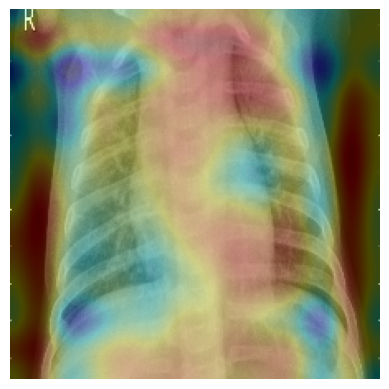

Model: VGG16 | Processing: person172_bacteria_828.jpeg
Heatmap for VGG16:


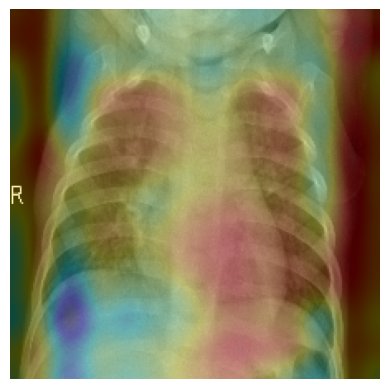

Model: VGG16 | Processing: IM-0006-0001.jpeg
Heatmap for VGG16:


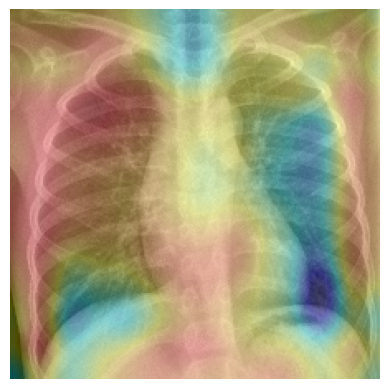

Model: VGG16 | Processing: IM-0065-0001.jpeg
Heatmap for VGG16:


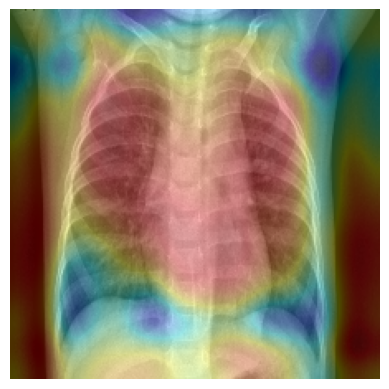

Model: ResNet50 | Processing: person70_virus_130.jpeg
Heatmap for ResNet50:


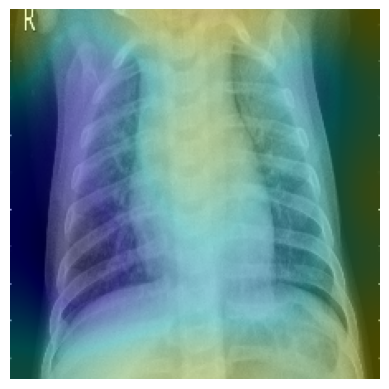

Model: ResNet50 | Processing: person172_bacteria_828.jpeg
Heatmap for ResNet50:


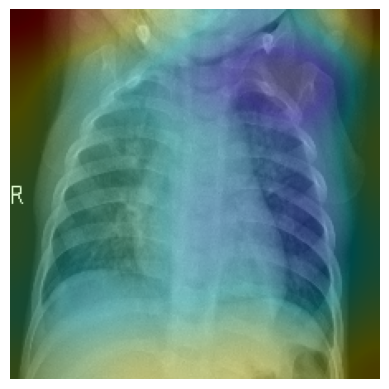

Model: ResNet50 | Processing: IM-0006-0001.jpeg
Heatmap for ResNet50:


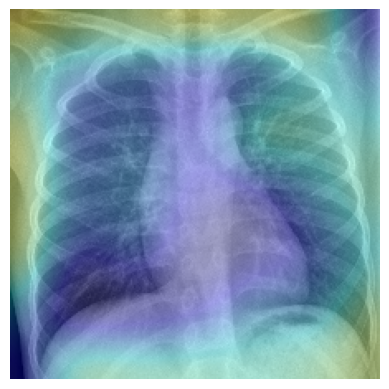

Model: ResNet50 | Processing: IM-0065-0001.jpeg
Heatmap for ResNet50:


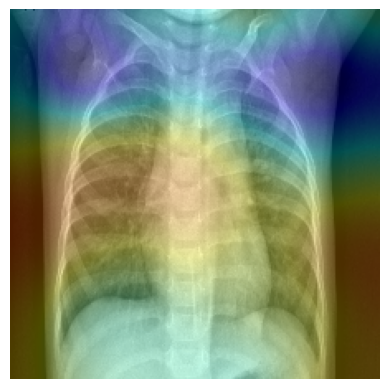

In [30]:
# VGG16 - pneumonia images
visualize_model_gradcam(
    directory=test_pneumonia_dir,
    model=vgg16_model,
    model_name="VGG16",
    layer_name="block5_conv3",
    n_images=2
)

# VGG16 - normal images
visualize_model_gradcam(
    directory=test_normal_dir,
    model=vgg16_model,
    model_name="VGG16",
    layer_name="block5_conv3",
    n_images=2
)


# ResNet50 - pneumonia images
visualize_model_gradcam(
    directory=test_pneumonia_dir,
    model=resnet50_model,
    model_name="ResNet50",
    layer_name="conv5_block3_out",
    n_images=2
)

# ResNet50 - normal images
visualize_model_gradcam(
    directory=test_normal_dir,
    model=resnet50_model,
    model_name="ResNet50",
    layer_name="conv5_block3_out",
    n_images=2
)

## Model Comparison - ResNet50 vs VGG16


> *Note: Due to the stochastic nature of Deep Learning (GPU non-determinism and random augmentation), results may slightly vary between runs even with fixed seeds. The following analysis is based on the trends observed across multiple training sessions, though the core behavior of each model remains consistent. The screenshots and metrics provided in this notebook represent a specific stable run used for this evaluation.*

### Accuracy Plot

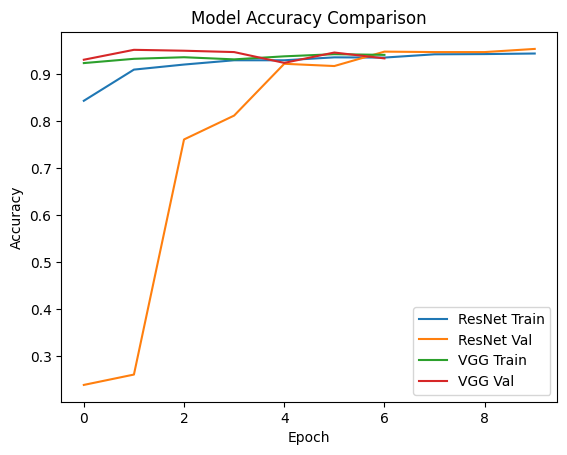

In [31]:
plt.figure()

plt.plot(resnet50_history.history['accuracy'], label='ResNet Train')
plt.plot(resnet50_history.history['val_accuracy'], label='ResNet Val')

plt.plot(vgg16_history.history['accuracy'], label='VGG Train')
plt.plot(vgg16_history.history['val_accuracy'], label='VGG Val')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Loss Plot

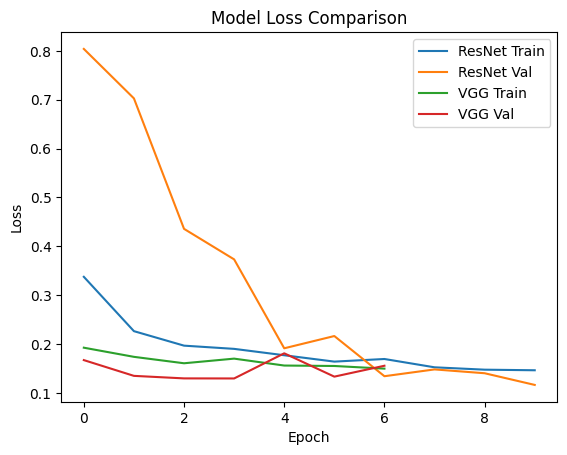

In [32]:
plt.figure()

plt.plot(resnet50_history.history['loss'], label='ResNet Train')
plt.plot(resnet50_history.history['val_loss'], label='ResNet Val')

plt.plot(vgg16_history.history['loss'], label='VGG Train')
plt.plot(vgg16_history.history['val_loss'], label='VGG Val')

plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Confusion Matrix & F1 Score

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 338ms/step


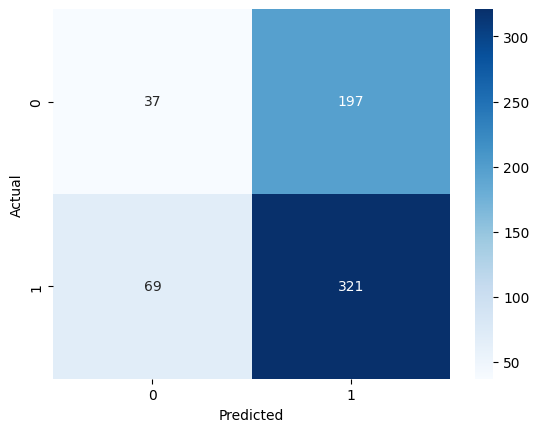

ResNet50:
              precision    recall  f1-score   support

         0.0       0.35      0.16      0.22       234
         1.0       0.62      0.82      0.71       390

    accuracy                           0.57       624
   macro avg       0.48      0.49      0.46       624
weighted avg       0.52      0.57      0.52       624

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step


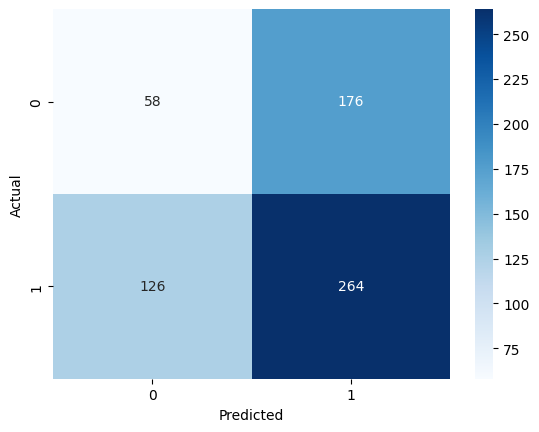

VGG16:
              precision    recall  f1-score   support

         0.0       0.32      0.25      0.28       234
         1.0       0.60      0.68      0.64       390

    accuracy                           0.52       624
   macro avg       0.46      0.46      0.46       624
weighted avg       0.49      0.52      0.50       624



In [37]:
# ResNet50
y_pred_resnet = resnet50_model.predict(test_ds)
y_pred_bool_resnet = (y_pred_resnet > 0.5).astype("int32")

# Actual labels
y_true_resnet = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm_resnet = confusion_matrix(y_true_resnet, y_pred_bool_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("ResNet50:")
# F1-score
print(classification_report(y_true_resnet, y_pred_bool_resnet))


# VGG16
y_pred_vgg = vgg16_model.predict(test_ds)
y_pred_bool_vgg = (y_pred_vgg > 0.5).astype("int32")

y_true_vgg = np.concatenate([y for x, y in test_ds], axis=0)

cm_vgg = confusion_matrix(y_true_vgg, y_pred_bool_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("VGG16:")
print(classification_report(y_true_vgg, y_pred_bool_vgg))

### Results and Comparison

In [38]:
print(f"ResNet50 Test Accuracy: {resnet50_acc:.4f}")
print(f"VGG16 Test Accuracy: {vgg16_acc:.4f}")

ResNet50 Test Accuracy: 0.7821
VGG16 Test Accuracy: 0.8750


#### **Accuracy & Loss Plots**

The models were evaluated based on their learning curves over 10 epochs. The comparison reveals a significant difference in how the two architectures converged:

*   **VGG16 Stability:** The VGG16 model (red/green lines) demonstrated exceptional stability. Notably, the training for VGG16 was terminated at Epoch 6 by the Early Stopping callback. This occurred because the model reached its optimal validation performance early, continuing training would have only led to overfitting without further clinical gain. The minimal gap between its training and validation curves suggests a robust and well-generalized feature extraction process.
*   **ResNet50 Convergence Issues:** The ResNet50 model (blue/orange lines) started with a much higher loss and lower accuracy. While it managed to improve significantly by epoch 4, the final epochs show a troubling trend.
*   **Conclusion:** In the final 2 epochs, the ResNet50 validation loss began to increase while validation accuracy dropped. This divergence is a clear indicator of overfitting. Despite its deeper architecture, ResNet50 struggled to maintain generalization, likely becoming too specialized on the training data noise compared to the more consistent VGG16.

#### **Confusion Matrix & F1 Score**
The performance metrics for ResNet50 reveal a major failure in model reliability:

1. **Poor Specificity:** The model struggled to identify healthy lungs, misclassifying 197 out of 234 normal cases as pneumonia (False Positives). This results in a very low precision (0.35) for the 'Normal' class.
2. **Clinical Risk:** With 69 False Negatives, the model missed too much amunt of actual pneumonia cases, which is unacceptable in a medical diagnostic context.
3. **Accuracy Trap:** While the overall accuracy is 57%, this is heavily skewed by the model's tendency to predict "Pneumonia" for almost every image.
4. **Conclusion:** Combined with the Grad-CAM findings (where ResNet50 focused on image edges), these metrics confirm that the model failed to learn relevant biological features. It is effectively guessing based on dataset imbalance or background noise.

VGG16:
1. **Slightly Better Discrimination:** VGG16 was more successful at identifying healthy lungs (58 True Negatives vs. ResNet's 37), showing that it learned slightly more distinct features than its counterpart.

2. **Higher Clinical Risk (False Negatives):** Paradoxically, VGG16 performed worse in terms of patient safety, failing to detect 126 pneumonia cases (False Negatives). This suggests that while it is less prone to blindly guessing pneumonia, it is not sensitive enough to detect subtle pathological patterns.

3. **F1-Score Comparison:** VGG16 achieved a lower F1-score for the Pneumonia class (0.64 vs ResNet's 0.71). However, ResNet's higher score is an artifact of its "predict everything as pneumonia" bias, rather than superior learning.

#### **Grad-CAM**

After evaluating the models, we compared their decision-making processes using **Grad-CAM (Gradient-weighted Class Activation Mapping)**. The results revealed a fascinating contrast in how these two architectures "see" medical data and highlight the limitations of deep learning in clinical settings.



**VGG16 Observations: High Sensitivity with "Anatomical Noise"**

*   **Targeted Localization:** VGG16 demonstrated much stronger activation within the lung parenchyma compared to ResNet50. This alignment with actual medical pathology explains its higher test accuracy (**87.50%**).
*   **Anatomical Artifacts:** However, a closer look at the heatmaps reveals that VGG16 is not perfect. In several samples, high-intensity "red zones" appear outside the lungs, specifically around the neck and axillary (armpit) regions.
*   **Clinical Implications:** While the model correctly identifies pneumonia patterns, it has also partially learned irrelevant anatomical features. This suggests the model might be using the patient's body structure or positioning as secondary "shortcuts" to confirm its diagnosis, which is a common challenge in medical imaging AI.

**ResNet50 Observations: Severe Shortcut Learning**

*   **Edge Bias:** ResNet50 failed to produce significant activations within the lung area. Its focus was almost entirely on the image boundaries, corners, and diaphragm edges.
*   **Shortcut Learning:** This is a classic case of the model "gaming" the dataset. Instead of learning pathology, it likely focused on peripheral artifacts (such as medical equipment markers, digital cropping styles, or image tags) to differentiate between classes. This led to a slightly lower test accuracy (**78.21%**) and near-zero clinical reliability.





#### **Conclusion on Model Reliability**

The Grad-CAM analysis proves that accuracy is not the only metric for success in medical AI.

1.  **VGG16** is the superior model in this study because it successfully captures lung-related pathologies, even if it is slightly "distracted" by other anatomical regions like the neck or axilla.
2.  **ResNet50** failed the interpretability test completely, as its decisions were based on background noise and image metadata rather than medical indicators.

**Future Improvements:** To refine these models, further steps should include automated lung cropping (using a segmentation mask) to isolate the regions of interest and stringent data augmentation to force the models to ignore non-pulmonary features.